****EDA****

***TASK 01 Understand the data before any charts***

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px



df = pd.read_csv("ames_housing.csv")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)

print(f"loaded Ames Housing: {df.shape[0]} houses, {df.shape[1]} columns")

loaded Ames Housing: 1460 houses, 11 columns


• Run the full checklist: shape, head, info, describe, value_counts on the categorical column, and a missing-value
map.

In [4]:
shape = df.shape

shape

(1460, 11)

• Run the full checklist: shape, head, info, describe, value_counts on the categorical column, and a missing-value
map.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            1460 non-null   int64  
 1   Neighborhood  1460 non-null   str    
 2   OverallQual   1460 non-null   int64  
 3   GrLivArea     1460 non-null   int64  
 4   YearBuilt     1460 non-null   int64  
 5   Bedrooms      1460 non-null   int64  
 6   FullBath      1460 non-null   int64  
 7   GarageCars    1460 non-null   int64  
 8   LotArea       1460 non-null   int64  
 9   SalePrice     1460 non-null   int64  
 10  LotFrontage   1212 non-null   float64
dtypes: float64(1), int64(9), str(1)
memory usage: 125.6 KB


In [6]:
df.head()

,Id,Neighborhood,OverallQual,GrLivArea,YearBuilt,Bedrooms,FullBath,GarageCars,LotArea,SalePrice,LotFrontage
0,1,BrkSide,4,1726,1963,4,1,2,9055,188300,64.0
1,2,CollgCr,6,2292,1921,5,2,2,12134,267200,42.0
2,3,BrkSide,5,2063,2001,3,2,2,9699,254400,77.0
3,4,Edwards,6,2379,1952,4,1,3,16192,230600,NaN
4,5,NoRidge,8,2339,1996,4,2,2,10937,390200,74.0


In [7]:
df.describe().round(0)

,Id,OverallQual,GrLivArea,YearBuilt,Bedrooms,FullBath,GarageCars,LotArea,SalePrice,LotFrontage
count,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1212.0
mean,730.0,5.0,1870.0,1961.0,4.0,2.0,2.0,12713.0,237645.0,70.0
std,422.0,2.0,462.0,31.0,1.0,1.0,1.0,4514.0,65093.0,22.0
min,1.0,1.0,656.0,1900.0,1.0,1.0,0.0,1500.0,92100.0,21.0
25%,366.0,4.0,1559.0,1935.0,3.0,2.0,1.0,10292.0,187550.0,55.0
50%,730.0,5.0,1846.0,1961.0,4.0,2.0,2.0,12694.0,230600.0,69.0
75%,1095.0,6.0,2163.0,1988.0,4.0,3.0,2.0,15152.0,276750.0,85.0
max,1460.0,10.0,4600.0,2010.0,6.0,4.0,4.0,115000.0,595000.0,138.0


In [8]:
df['Neighborhood'].value_counts()

Neighborhood
OldTown    182
CollgCr    166
BrkSide    148
Edwards    146
Gilbert    140
NWAmes     125
Somerst    117
BrDale      77
IDOTRR      67
Timber      61
MeadowV     60
NridgHt     51
NoRidge     49
StoneBr     44
Veenker     27
Name: count, dtype: int64

In [9]:
df.isnull().sum()[df.isnull().sum() > 0]

LotFrontage    248
dtype: int64

• Write down: how many rows and columns? Which column has missing data, and what fraction is missing?

In [10]:
print(f"From the data we have rows {shape[0]} and columns {shape[1]}")


df.isna().sum()

missing_fraction = df.isna().mean()

print(missing_fraction)

From the data we have rows 1460 and columns 11
Id              0.000000
Neighborhood    0.000000
OverallQual     0.000000
GrLivArea       0.000000
YearBuilt       0.000000
Bedrooms        0.000000
FullBath        0.000000
GarageCars      0.000000
LotArea         0.000000
SalePrice       0.000000
LotFrontage     0.169863
dtype: float64


• From describe(), spot anything suspicious — a max far above the 75th percentile, a mean far from the
median, an impossible minimum. Note what you find.

In [11]:
'''LotArea and GrLivArea have unusually high maximum values compared with their 75th percentiles, suggesting possible outliers.
 LotFrontage has 248 missing values, but no clearly impossible minimum values.'''

'LotArea and GrLivArea have unusually high maximum values compared with their 75th percentiles, suggesting possible outliers.\n LotFrontage has 248 missing values, but no clearly impossible minimum values.'

**• State, in one sentence each, what SalePrice's rough range and typical value are.**


Rough range: SalePrice ranges from about $92,100 to $595,000.
Typical value: The typical house sells for around $230,600 (median).

***TASK 02 Univariate — each variable's own shape***

• Plot the distribution of SalePrice (histogram). Is it skewed? Which way?

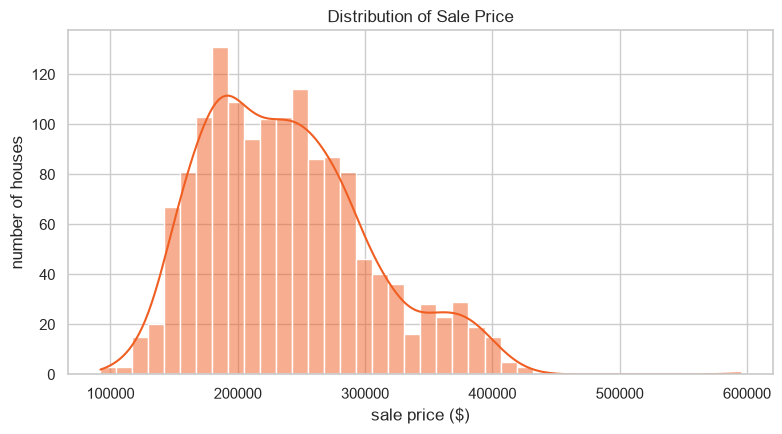

In [12]:
fig, ax = plt.subplots()
sns.histplot(df["SalePrice"], bins=40, kde=True, color="#F05E22", ax=ax)
ax.set_title("Distribution of Sale Price")
ax.set_xlabel("sale price ($)"); ax.set_ylabel("number of houses")
plt.tight_layout(); plt.show()

• Plot the distribution of at least two other numeric columns (e.g. GrLivArea, LotArea, YearBuilt).

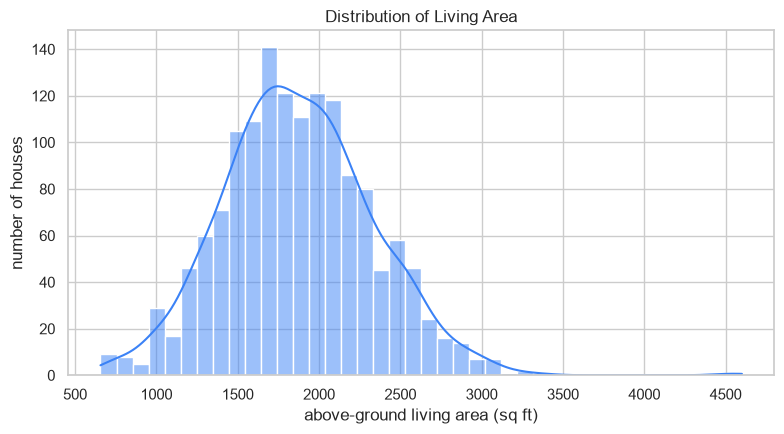

In [13]:
fig, ax = plt.subplots()
sns.histplot(df["GrLivArea"], bins=40, kde=True, color="#3B82F6", ax=ax)
ax.set_title("Distribution of Living Area")
ax.set_xlabel("above-ground living area (sq ft)"); ax.set_ylabel("number of houses")
plt.tight_layout(); plt.show()

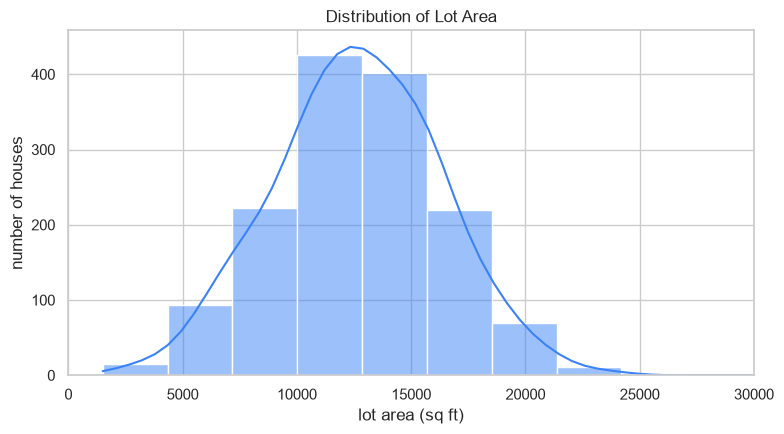

In [14]:
fig, ax = plt.subplots()
sns.histplot(df["LotArea"], bins=40, kde=True, color="#3B82F6", ax=ax)

plt.xlim(0, 30000)
ax.set_title("Distribution of Lot Area")
ax.set_xlabel("lot area (sq ft)"); ax.set_ylabel("number of houses")
plt.tight_layout(); plt.show()

• Plot a count of a categorical or discrete column (OverallQual, or Bedrooms).

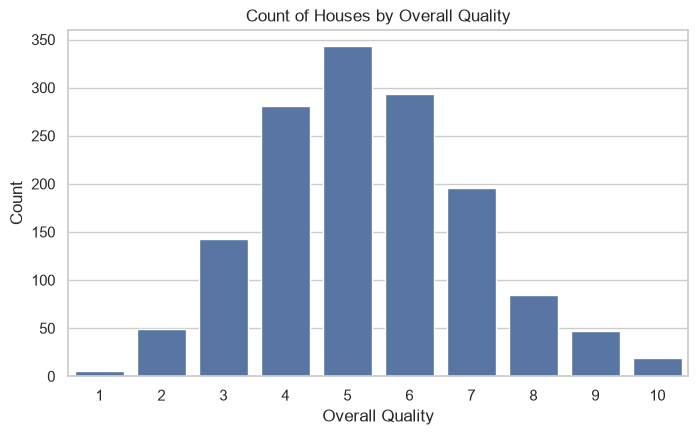

In [15]:
sns.countplot(data=df, x="OverallQual")

plt.title("Count of Houses by Overall Quality")
plt.xlabel("Overall Quality")
plt.ylabel("Count")
plt.show()

**• For each, write one line: what is this variable's shape, and does anything stand out?**

SalePrice: Right-skewed, with a long tail toward higher prices.

OverallQual: Discrete/ordinal distribution, concentrated around quality levels 5–6.

Bedrooms: Discrete distribution, mostly around 3–4 bedrooms, with fewer houses at the extremes.

***TASK 03 Bivariate — what drives price?***

• Scatter plot: GrLivArea vs SalePrice. Describe the relationship in one line. Do you see any points that break the
pattern?

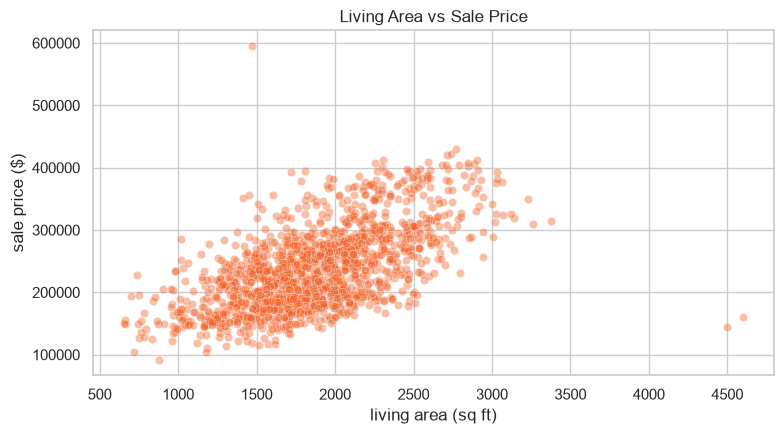

In [16]:
fig, ax = plt.subplots()
sns.scatterplot(data=df, x="GrLivArea", y="SalePrice", alpha=0.4, color="#F05E22", ax=ax)
ax.set_title("Living Area vs Sale Price")
ax.set_xlabel("living area (sq ft)"); ax.set_ylabel("sale price ($)")
plt.tight_layout(); plt.show()

• Boxplot: SalePrice across OverallQual levels. Does price climb with quality?

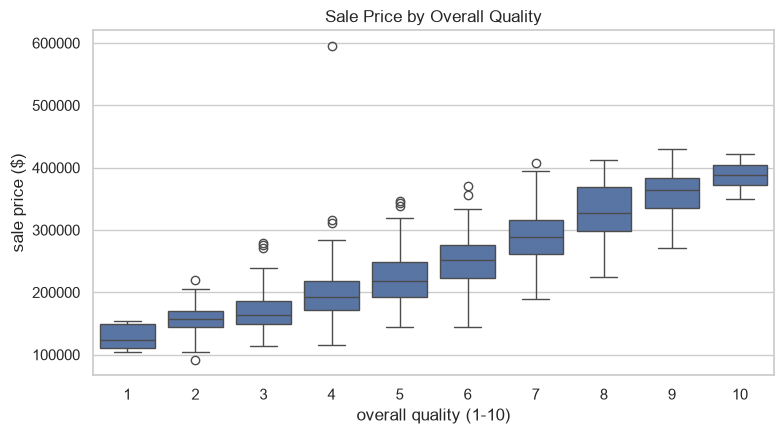

In [17]:
fig, ax = plt.subplots()
sns.boxplot(x="OverallQual", y="SalePrice", data=df, ax=ax)
ax.set_title("Sale Price by Overall Quality")
ax.set_xlabel("overall quality (1-10)"); ax.set_ylabel("sale price ($)")
plt.tight_layout(); plt.show()

• Boxplot: SalePrice by Neighborhood — and sort the neighborhoods by median price so it reads as a ranking.

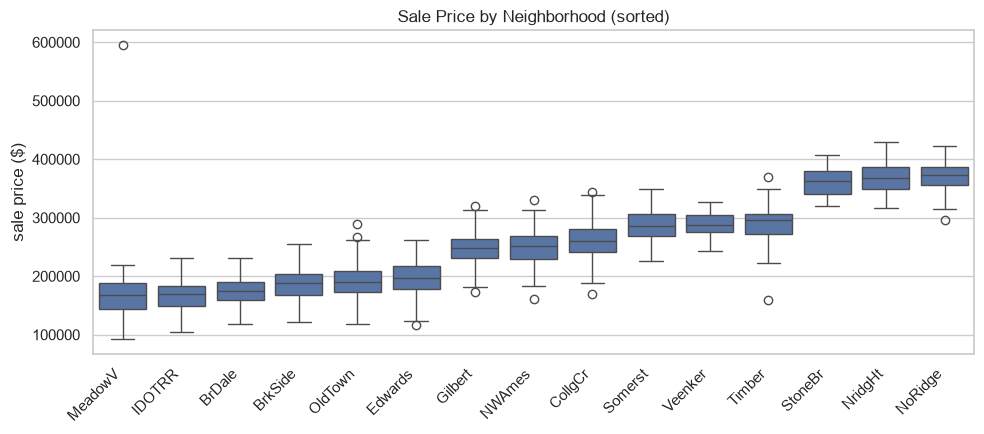

In [18]:
order = df.groupby("Neighborhood")["SalePrice"].median().sort_values().index
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(x="Neighborhood", y="SalePrice", data=df, order=order , ax=ax)
ax.set_title("Sale Price by Neighborhood (sorted)")
ax.set_xlabel(""); ax.set_ylabel("sale price ($)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

• Pick one more pair of variables you're curious about and plot their relationship.

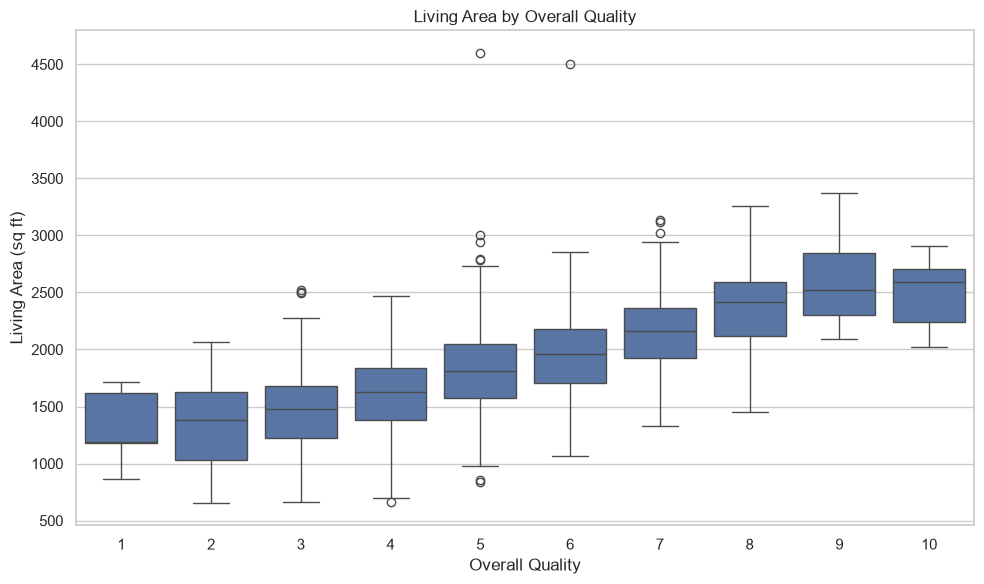

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="OverallQual",
    y="GrLivArea",
    ax=ax
)

ax.set_title("Living Area by Overall Quality")
ax.set_xlabel("Overall Quality")
ax.set_ylabel("Living Area (sq ft)")

plt.tight_layout()
plt.show()

***TASK 04 Multivariate — the whole picture***

• Build a correlation heatmap of all numeric columns. Read off: which variable correlates most strongly with
SalePrice?

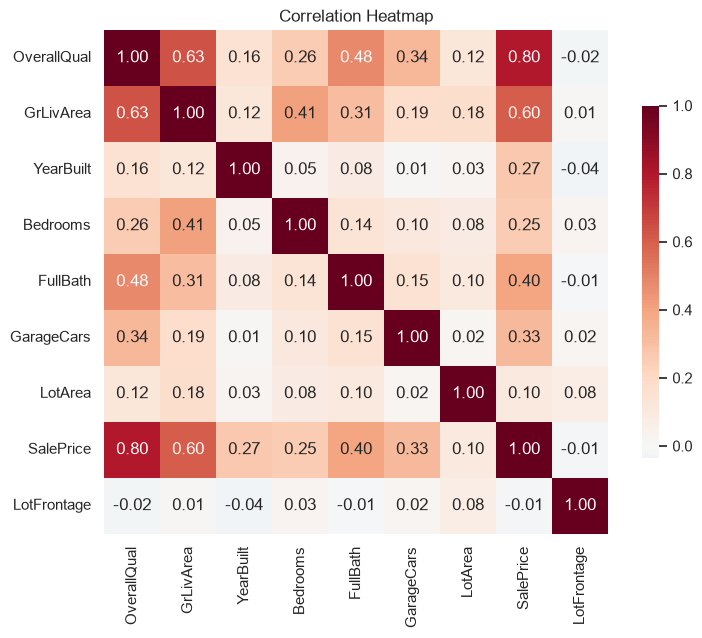

In [20]:
numeric = df.select_dtypes("number").drop(columns=["Id"])
corr = numeric.corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout(); plt.show()

• Make a scatter plot that encodes a THIRD variable as colour (e.g. area vs price, coloured by quality).

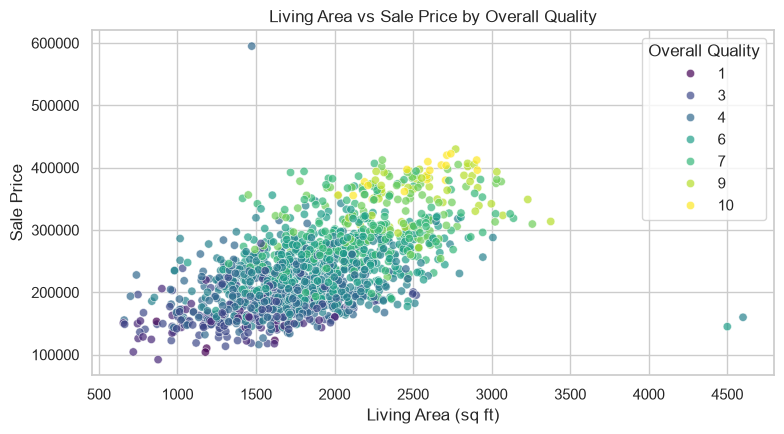

In [21]:
sns.scatterplot( data=df, x="GrLivArea", y="SalePrice", hue="OverallQual", palette="viridis", alpha=0.7 )

plt.title("Living Area vs Sale Price by Overall Quality")
plt.xlabel("Living Area (sq ft)")
plt.ylabel("Sale Price")
plt.legend(title="Overall Quality")

plt.tight_layout()
plt.show()

• Make one interactive plotly chart — a scatter you can hover, with extra details in the tooltip.

In [22]:
fig = px.scatter(df, x="GrLivArea", y="SalePrice", color="OverallQual",
                 hover_data=["Neighborhood", "YearBuilt"],
                 title="Interactive: Area vs Price (hover for details)",
                 labels={"GrLivArea": "living area (sq ft)", "SalePrice": "sale price ($)"},
                 color_continuous_scale="viridis")
fig.update_layout(width=800, height=500)
fig.show()

• From the heatmap, write down the top 3 drivers of price in order.

In [23]:
'''the top 3 drivers of SalePrice are:

1.OverallQual → 0.80
2.GrLivArea → 0.60
3.FullBath → 0.40
'''

'the top 3 drivers of SalePrice are:\n\n1.OverallQual → 0.80\n2.GrLivArea → 0.60\n3.FullBath → 0.40\n'

***TASK 05 Hunt the outliers***

• Draw a boxplot of SalePrice and identify the outlier dots.

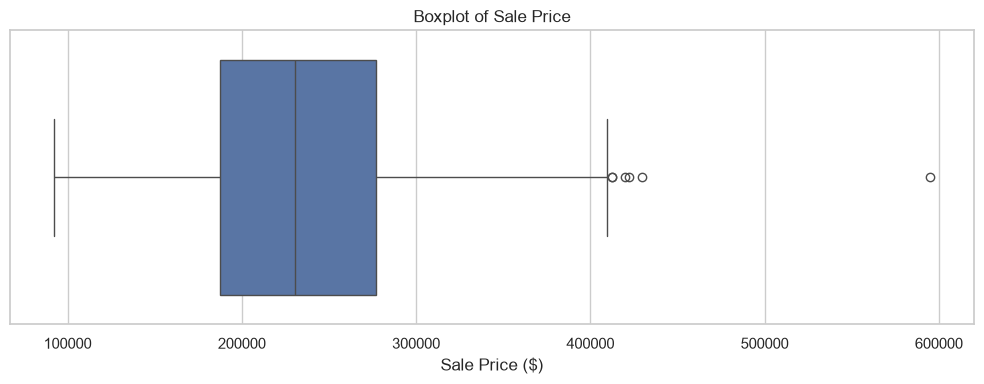

In [24]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df["SalePrice"])

plt.title("Boxplot of Sale Price")
plt.xlabel("Sale Price ($)")

plt.tight_layout()
plt.show()

• Apply the IQR method in code to flag price outliers with a precise rule (below Q1 minus 1.5xIQR, or above Q3
plus 1.5xIQR).

In [25]:
Q1 = df["SalePrice"].quantile(0.25)
Q3 = df["SalePrice"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["SalePrice"] < lower) |
    (df["SalePrice"] > upper)
]

print("Lower limit:", lower)
print("Upper limit:", upper)
print("Number of outliers:", len(outliers))

Lower limit: 53750.0
Upper limit: 410550.0
Number of outliers: 6


• For each outlier you find, write one line: is it likely a genuine rarity or an error, and what would you do about it?


==> SalePrice outliers: Likely genuine expensive houses, so I would keep them after verifying the original data.

TASK 06 Try plotnine (ggplot grammar)

• Install and import plotnine. Recreate any one of your earlier charts using its ggplot-style grammar.

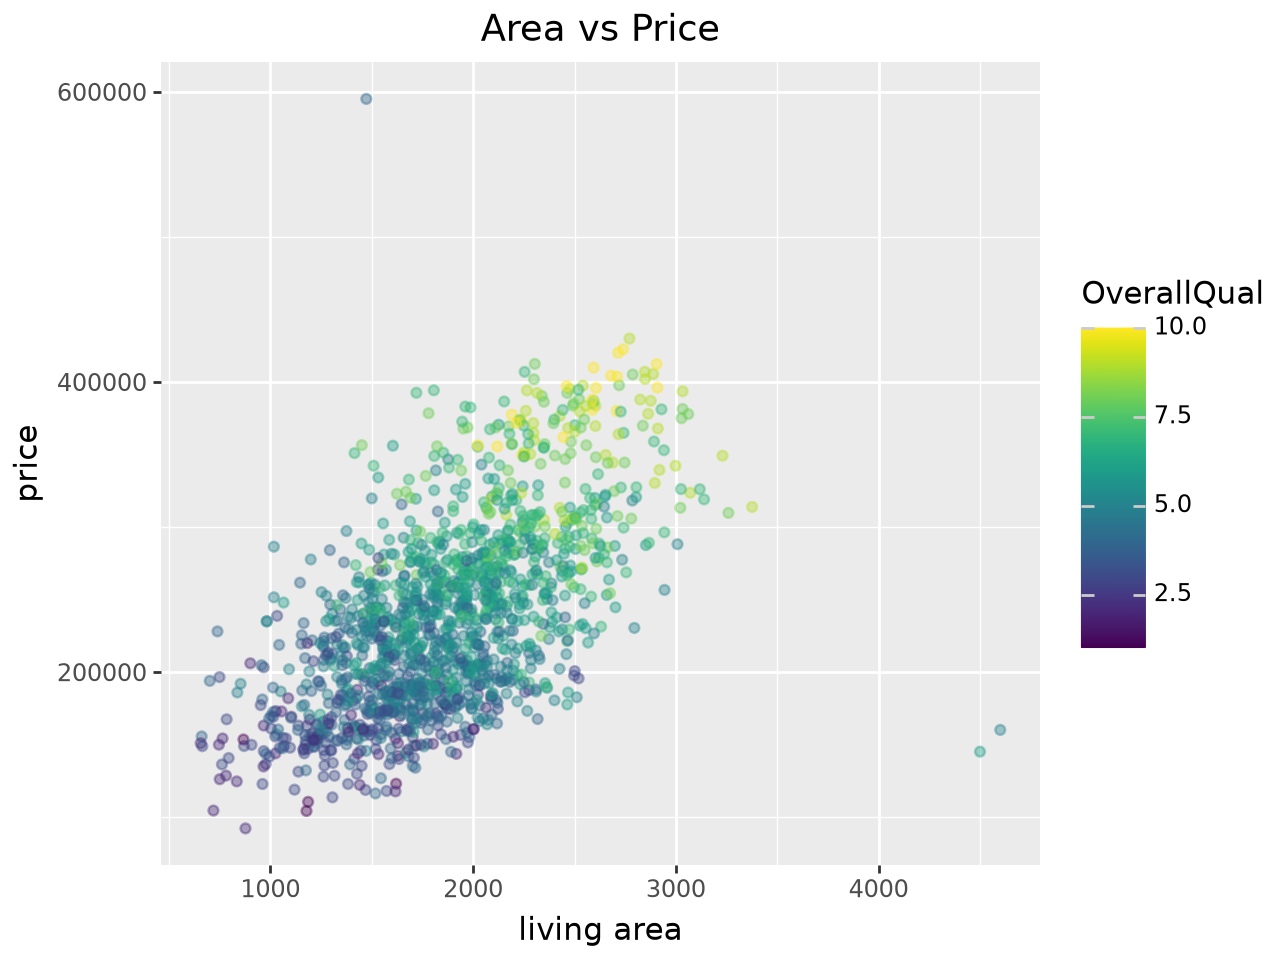

In [27]:
from plotnine import ggplot, aes, geom_point, labs
(ggplot(df, aes('GrLivArea', 'SalePrice', color='OverallQual'))
+ geom_point(alpha=0.4)
+ labs(title='Area vs Price', x='living area', y='price'))

• Notice how it builds a chart in layers: data, then aesthetics (which column maps to x, y, colour), then geoms
(points, bars).

In [30]:
'''Plotnine builds charts in layers: first the data is provided,
then aes() maps columns to aesthetics such as x, y, and colour,
and finally a geom determines what is drawn, such as points or bars.'''

'Plotnine builds charts in layers: first the data is provided,\nthen aes() maps columns to aesthetics such as x, y, and colour,\nand finally a geom determines what is drawn, such as points or bars.'

• Write two sentences comparing the plotnine style to seaborn — which felt more natural to you, and why?

In [31]:
'''I found Seaborn more natural because its syntax is simpler and more direct for creating charts.
 Plotnine is more structured and flexible with its layer-based approach, but it takes a little more time to get used to.'''

'I found Seaborn more natural because its syntax is simpler and more direct for creating charts.\n Plotnine is more structured and flexible with its layer-based approach, but it takes a little more time to get used to.'